In [121]:
import sys
print(sys.executable)
import matplotlib
print(matplotlib.__file__)

/Users/annali/opt/anaconda3/bin/python
/Users/annali/opt/anaconda3/lib/python3.9/site-packages/matplotlib/__init__.py


In [123]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
import joblib

In [135]:
print("Loading data...")
df = pd.read_parquet("../Data/Parquet/New_estchlsummed.parquet")

# Remove rows with missing Secchi
df = df[df['Secchi'].notna()].copy()

print(f"Total observations: {len(df)}")

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

Loading data...
Total observations: 1971


# Simple Regression

In [136]:
print("\n" + "="*80)
print("LINEAR REGRESSION - EXPLICIT EQUATION")
print("="*80)

# Define predictors
predictors = ['ESTCHL_SUMMED', 'XMISS_SUMMED', 'K_PAR_SLOPE', 'DEPTH']
target = np.log(df['Secchi'])

# Prepare data
X = df[predictors].copy()
y = target.copy()

# Remove rows with missing target
mask = y.notna() & (y > 0)
X = X[mask]
y = y[mask]

print(f"\nPredictors: {predictors}")
print(f"Target: {target}")
print(f"Sample size: {len(X)}")

# Check for missing values in predictors
print(f"\nMissing values:")
for col in predictors:
    missing = X[col].isna().sum()
    print(f"  {col}: {missing} ({missing/len(X)*100:.1f}%)")


LINEAR REGRESSION - EXPLICIT EQUATION

Predictors: ['ESTCHL_SUMMED', 'XMISS_SUMMED', 'K_PAR_SLOPE', 'DEPTH']
Target: 0       3.135494
1       2.944439
2       3.218876
3       3.433987
4       3.367296
          ...   
1966    2.397895
1967    2.772589
1968    2.484907
1969    2.772589
1970    3.433987
Name: Secchi, Length: 1971, dtype: float64
Sample size: 1970

Missing values:
  ESTCHL_SUMMED: 0 (0.0%)
  XMISS_SUMMED: 0 (0.0%)
  K_PAR_SLOPE: 0 (0.0%)
  DEPTH: 0 (0.0%)


In [137]:
# Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 1576
Test size: 394


In [138]:
# Fit Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

# Print equation
print("\n" + "="*80)
print("LINEAR REGRESSION EQUATION")
print("="*80)

print(f"\nSecchi = ", end="")
for i, (coef, pred) in enumerate(zip(lr.coef_, predictors)):
    if i == 0:
        print(f"{coef:.6f} × {pred}", end="")
    else:
        if coef >= 0:
            print(f" + {coef:.6f} × {pred}", end="")
        else:
            print(f" - {abs(coef):.6f} × {pred}", end="")

print(f" + {lr.intercept_:.6f}")

# Print in more readable format
print(f"\n\nCoefficients:")
for pred, coef in zip(predictors, lr.coef_):
    print(f"  {pred:20s}: {coef:+.6f}")
print(f"  {'Intercept':20s}: {lr.intercept_:+.6f}")


LINEAR REGRESSION EQUATION

Secchi = -0.007500 × ESTCHL_SUMMED + 0.000020 × XMISS_SUMMED + 0.007923 × K_PAR_SLOPE + 0.013121 × DEPTH + 2.401755


Coefficients:
  ESTCHL_SUMMED       : -0.007500
  XMISS_SUMMED        : +0.000020
  K_PAR_SLOPE         : +0.007923
  DEPTH               : +0.013121
  Intercept           : +2.401755


In [139]:
# Evaluate Linear Regression

print("\n" + "="*80)
print("LINEAR REGRESSION PERFORMANCE")
print("="*80)

# Cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train, y_train, cv=kfold, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(lr, X_train, y_train, cv=kfold, 
                                   scoring='neg_mean_squared_error'))

print(f"\n5-Fold Cross-Validation:")
print(f"  CV R²:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

# Predictions
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Training performance
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"\nTraining Performance:")
print(f"  R²:   {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} m")
print(f"  MAE:  {train_mae:.4f} m")

# Test performance
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\nTest Performance:")
print(f"  R²:   {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} m")
print(f"  MAE:  {test_mae:.4f} m")



LINEAR REGRESSION PERFORMANCE

5-Fold Cross-Validation:
  CV R²:   0.6514 ± 0.0394
  CV RMSE: 0.2927 ± 0.0242

Training Performance:
  R²:   0.6563
  RMSE: 0.2920 m
  MAE:  0.2204 m

Test Performance:
  R²:   0.6360
  RMSE: 0.3024 m
  MAE:  0.2308 m


Saved: ../results/linear_regression_results.png


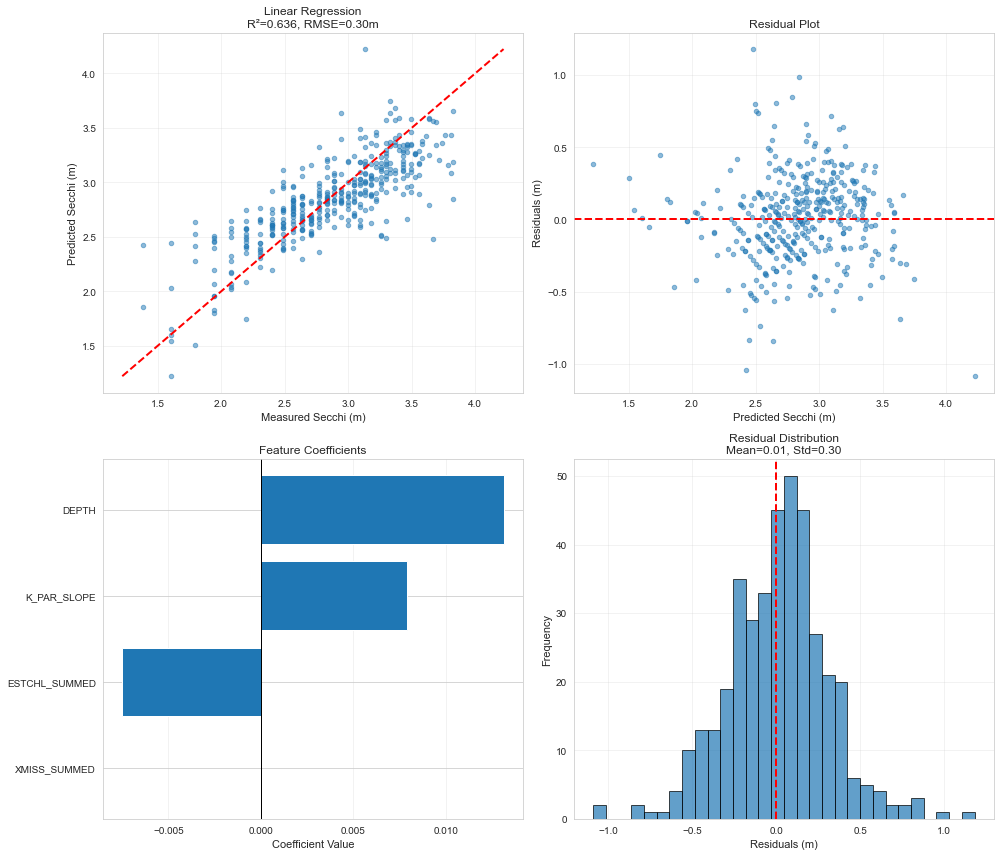


LINEAR REGRESSION COMPLETE!


In [140]:
# Visuals
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0, 0].set_xlabel('Measured Secchi (m)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Secchi (m)', fontsize=11)
axes[0, 0].set_title(f'Linear Regression\nR²={test_r2:.3f}, RMSE={test_rmse:.2f}m', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Secchi (m)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (m)', fontsize=11)
axes[0, 1].set_title('Residual Plot', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Coefficient importance
coef_df = pd.DataFrame({
    'Feature': predictors,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

axes[1, 0].barh(range(len(coef_df)), coef_df['Coefficient'])
axes[1, 0].set_yticks(range(len(coef_df)))
axes[1, 0].set_yticklabels(coef_df['Feature'])
axes[1, 0].set_xlabel('Coefficient Value', fontsize=11)
axes[1, 0].set_title('Feature Coefficients', fontsize=12)
axes[1, 0].axvline(0, color='black', linestyle='-', lw=1)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Residual histogram
axes[1, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals (m)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title(f'Residual Distribution\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}', 
                     fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "linear_regression_results.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'linear_regression_results.png'}")
plt.show()

print("\n" + "="*80)
print("LINEAR REGRESSION COMPLETE!")
print("="*80)

# Symbolical Regression

In [106]:
!pip install gplearn

zsh:1: command not found: pip


In [141]:
from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function
import warnings
warnings.filterwarnings('ignore')

In [142]:
# Configure Symbolic Regressor

sr = SymbolicRegressor(
    population_size=5000,        # Number of programs in each generation
    generations=20,              # Number of generations to evolve
    stopping_criteria=0.01,      # Stop if fitness is better than this
    p_crossover=0.7,            # Probability of crossover
    p_subtree_mutation=0.1,     # Probability of subtree mutation
    p_hoist_mutation=0.05,      # Probability of hoist mutation
    p_point_mutation=0.1,       # Probability of point mutation
    max_samples=0.9,            # Fraction of samples for fitness
    verbose=1,                  # Print progress
    parsimony_coefficient=0.01, # Penalty for complex equations
    random_state=42,
    n_jobs=-1                   # Use all CPU cores
)

sr.fit(X_train, y_train)

# Best formula
print("\n" + "="*80)
print("SYMBOLIC REGRESSION - BEST EQUATION FOUND")
print("="*80)

print(f"\nBest formula:")
print(f"{sr._program}")

# Convert to more readable format
formula_str = str(sr._program)
print(f"\nReadable formula:")
print(f"Secchi = {formula_str}")

# Evaluate Symbolic Regression
print("\n" + "="*80)
print("SYMBOLIC REGRESSION PERFORMANCE")
print("="*80)

# Predictions
y_train_pred_sr = sr.predict(X_train)
y_test_pred_sr = sr.predict(X_test)

# Training performance
train_r2_sr = r2_score(y_train, y_train_pred_sr)
train_rmse_sr = np.sqrt(mean_squared_error(y_train, y_train_pred_sr))

print(f"\nTraining Performance:")
print(f"  R²:   {train_r2_sr:.4f}")
print(f"  RMSE: {train_rmse_sr:.4f} m")

# Test performance
test_r2_sr = r2_score(y_test, y_test_pred_sr)
test_rmse_sr = np.sqrt(mean_squared_error(y_test, y_test_pred_sr))
test_mae_sr = mean_absolute_error(y_test, y_test_pred_sr)

print(f"\nTest Performance:")
print(f"  R²:   {test_r2_sr:.4f}")
print(f"  RMSE: {test_rmse_sr:.4f} m")
print(f"  MAE:  {test_mae_sr:.4f} m")



    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left


/Users/annali/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/annali/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/annali/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/annali/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently instal

   0    30.42      3.15624e+22        5         0.502383         0.467545      3.20m
   1    10.85      1.24256e+09        5         0.415364         0.471368      1.35m
   2     7.54      1.04915e+08       13         0.396947         0.404779      1.17m
   3     7.64      2.78107e+07       13         0.394272         0.428788      1.66m
   4     8.00           176311       13         0.280935         0.280646     58.83s
   5     6.28      1.06698e+14       13         0.272647         0.279747     57.88s
   6     5.52      2.61445e+09       13         0.272791         0.278454     56.97s
   7     6.05      2.05877e+06       13         0.266351         0.336252     46.91s
   8     8.17      9.52753e+19       13         0.268278          0.31896     43.75s
   9     9.79      1.27528e+16       13         0.264973         0.348623     44.79s
  10     8.00           220971       11         0.266345         0.347698     37.18s
  11     7.11      1.17582e+06       11         0.270037         

# Polynomial Regression

In [ ]:
# Degree 3 polynomial regression
predictors_poly = ['ESTCHL_SUMMED', 'K_PAR_SLOPE', 'DEPTH']
X = df[predictors_poly].copy()
y = np.log(df['Secchi'])

mask = y.notna() & (y > 0)
X, y = X[mask], y[mask]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n" + "="*80)
print("POLYNOMIAL REGRESSION (DEGREE 3)")
print("="*80)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_p)
X_test_poly = poly.transform(X_test_p)

poly_feature_names = poly.get_feature_names_out(predictors_poly)

print(f"\nOriginal features: {len(predictors_poly)}")
print(f"Polynomial features: {len(poly_feature_names)}")

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train_p)

y_pred_poly = lr_poly.predict(X_test_poly)
r2_poly = r2_score(y_test_p, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test_p, y_pred_poly))

print(f"\nPolynomial Regression Performance:")
print(f"  R²:   {r2_poly:.4f}")
print(f"  RMSE: {rmse_poly:.4f} m")

coef_poly_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': lr_poly.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n\nTop 10 Most Important Terms:")
print(coef_poly_df.head(10).to_string(index=False))

with open(results_dir / "polynomial_regression_degree3_equation.txt", 'w') as f:
    f.write("POLYNOMIAL REGRESSION EQUATION FOR SECCHI DEPTH (DEGREE 3)\n")
    f.write("="*80 + "\n\n")
    f.write("LOG(Secchi) = ")
    for i, (coef, feat) in enumerate(zip(lr_poly.coef_, poly_feature_names)):
        if i == 0:
            f.write(f"{coef:.6f} × {feat}")
        else:
            if coef >= 0:
                f.write(f"\n       + {coef:.6f} × {feat}")
            else:
                f.write(f"\n       - {abs(coef):.6f} × {feat}")
    f.write(f"\n       + {lr_poly.intercept_:.6f}\n\n")
    f.write(f"Performance:\n")
    f.write(f"  R²:   {r2_poly:.4f}\n")
    f.write(f"  RMSE: {rmse_poly:.4f} m\n")

print(f"\nEquation saved to: {results_dir / 'polynomial_regression_degree3_equation.txt'}")


POLYNOMIAL REGRESSION (DEGREE 3)

Original features: 3
Polynomial features: 19

Polynomial Regression Performance:
  R²:   0.7415
  RMSE: 0.2549 m


Top 10 Most Important Terms:
                    Feature  Coefficient
                K_PAR_SLOPE     0.448913
              K_PAR_SLOPE^2    -0.088208
  ESTCHL_SUMMED K_PAR_SLOPE    -0.046434
                      DEPTH     0.025872
              ESTCHL_SUMMED     0.004633
          K_PAR_SLOPE DEPTH     0.004032
        K_PAR_SLOPE^2 DEPTH     0.003667
              K_PAR_SLOPE^3     0.003172
ESTCHL_SUMMED K_PAR_SLOPE^2     0.002669
        K_PAR_SLOPE DEPTH^2    -0.001111

Equation saved to: ../results/polynomial_regression_degree3_equation.txt


In [154]:
# Degree 2 polynomial regression

print("\n" + "="*80)
print("POLYNOMIAL REGRESSION (DEGREE 2)")
print("="*80)

poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train_p)
X_test_poly2 = poly2.transform(X_test_p)

poly_feature_names2 = poly2.get_feature_names_out(predictors_poly)

print(f"\nOriginal features: {len(predictors_poly)}")
print(f"Polynomial features: {len(poly_feature_names2)}")

lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train_p)

y_pred_poly2 = lr_poly2.predict(X_test_poly2)
r2_poly2 = r2_score(y_test_p, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test_p, y_pred_poly2))

print(f"\nPolynomial Regression Performance:")
print(f"  R²:   {r2_poly2:.4f}")
print(f"  RMSE: {rmse_poly2:.4f} m")

coef_poly_df2 = pd.DataFrame({
    'Feature': poly_feature_names2,
    'Coefficient': lr_poly2.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n\nTop 10 Most Important Terms:")
print(coef_poly_df2.head(10).to_string(index=False))

with open(results_dir / "polynomial_regression_degree2_equation.txt", 'w') as f:
    f.write("POLYNOMIAL REGRESSION EQUATION FOR SECCHI DEPTH (DEGREE 2)\n")
    f.write("="*80 + "\n\n")
    f.write("LOG(Secchi) = ")
    for i, (coef, feat) in enumerate(zip(lr_poly2.coef_, poly_feature_names2)):
        if i == 0:
            f.write(f"{coef:.6f} × {feat}")
        else:
            if coef >= 0:
                f.write(f"\n       + {coef:.6f} × {feat}")
            else:
                f.write(f"\n       - {abs(coef):.6f} × {feat}")
    f.write(f"\n       + {lr_poly2.intercept_:.6f}\n\n")
    f.write("Performance:\n")
    f.write(f"  R²:   {r2_poly2:.4f}\n")
    f.write(f"  RMSE: {rmse_poly2:.4f} m\n")

print(f"\nEquation saved to: {results_dir / 'polynomial_regression_degree2_equation.txt'}")


POLYNOMIAL REGRESSION (DEGREE 2)

Original features: 3
Polynomial features: 9

Polynomial Regression Performance:
  R²:   0.7039
  RMSE: 0.2728 m


Top 10 Most Important Terms:
                  Feature  Coefficient
              K_PAR_SLOPE     0.137695
                    DEPTH     0.020639
ESTCHL_SUMMED K_PAR_SLOPE    -0.015728
        K_PAR_SLOPE DEPTH    -0.012623
            ESTCHL_SUMMED    -0.003732
            K_PAR_SLOPE^2    -0.001702
      ESTCHL_SUMMED DEPTH    -0.000350
                  DEPTH^2    -0.000087
          ESTCHL_SUMMED^2     0.000039

Equation saved to: ../results/polynomial_regression_degree2_equation.txt


Conclusion: Polynomial regression (3 predictors: 'ESTCHL_SUMMED', 'K_PAR_SLOPE', 'DEPTH') 

1. Degree 3: higher R^2 and lower RMSE, more complicated & longer equation
    R²:   0.7415
    RMSE: 0.2549 m
2. Degree 2: lower R^2 and higher RMSE, less complicated equation
    R²:   0.7039
    RMSE: 0.2728 m

# Trying Regular RF

In [ ]:
def train_random_forest(X, y, feature_names, model_name, n_estimators=100, test_size=0.2):
    """
    Train Random Forest with train/test split and 5-fold cross-validation
    """
    print(f"\n{'='*60}")
    print(f"Training Random Forest: {model_name}")
    print(f"{'='*60}")

    # Split data into train and test (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\nData split:")
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set:     {len(X_test)} samples")
    print(f"  Number of features: {X.shape[1]}")

    # Initialize Random Forest
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1,  # Use all CPU cores
        max_depth=10,  # Prevent overfitting
        min_samples_split=5
    )

    # 5-fold cross-validation ON TRAINING DATA ONLY
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Cross-validation scores
    cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)

    print(f"\n5-Fold Cross-Validation RMSE (on training data):")
    print(f"  Mean: {cv_rmse.mean():.4f}")
    print(f"  Std:  {cv_rmse.std():.4f}")

    # R² scores
    cv_r2 = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='r2')
    print(f"\n5-Fold Cross-Validation R² (on training data):")
    print(f"  Mean: {cv_r2.mean():.4f}")
    print(f"  Std:  {cv_r2.std():.4f}")
    
    # Train final model on all training data
    rf.fit(X_train, y_train)

    # Predictions on training data
    y_train_pred = rf.predict(X_train)

    # Training metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    print(f"\nTraining Set Performance:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")
    print(f"  R²:   {train_r2:.4f}")

    # Predictions on test data
    y_test_pred = rf.predict(X_test)

    # Test metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"\nTest Set Performance:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")
    print(f"  R²:   {test_r2:.4f}")

    # Feature importance
    print(f"\nTop 10 Most Important Features:")
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(feature_importance.head(10).to_string(index=False))

    return {
        'model': rf,
        'cv_rmse': cv_rmse,
        'cv_r2': cv_r2,
        'X_train': X_train,
        'y_train': y_train,
        'y_train_pred': y_train_pred,
        'X_test': X_test,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'feature_importance': feature_importance
    }

X = df[["ESTCHL_SUMMED", "K_PAR", "XMISS_SUMMED"]]
y = df["Secchi"]

res = train_random_forest(
    X,
    y,
    X.columns,
    "rf_overall_all_features"
)



Training Random Forest: rf_overall_all_features

Data split:
  Training set: 1576 samples
  Test set:     395 samples
  Number of features: 3

5-Fold Cross-Validation RMSE (on training data):
  Mean: 4.3702
  Std:  0.2353

5-Fold Cross-Validation R² (on training data):
  Mean: 0.7486
  Std:  0.0176

Training Set Performance:
  RMSE: 2.5470
  MAE:  1.9330
  R²:   0.9149

Test Set Performance:
  RMSE: 4.4390
  MAE:  3.4056
  R²:   0.7460

Top 10 Most Important Features:
      feature  importance
ESTCHL_SUMMED    0.810935
        K_PAR    0.119563
 XMISS_SUMMED    0.069502


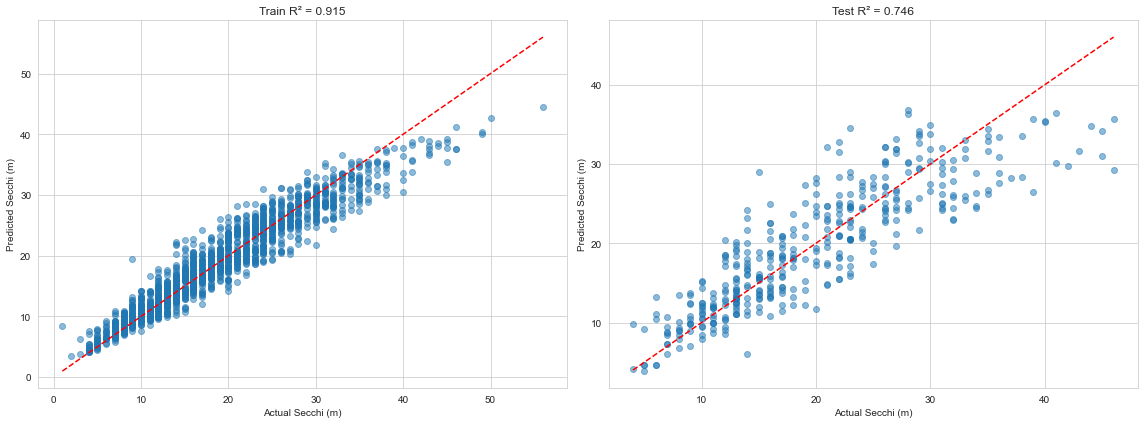

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Train
axes[0].scatter(res['y_train'], res['y_train_pred'], alpha=0.5)
axes[0].plot([res['y_train'].min(), res['y_train'].max()],
             [res['y_train'].min(), res['y_train'].max()], 'r--')
axes[0].set_title(f"Train R² = {res['train_r2']:.3f}")
axes[0].set_xlabel("Actual Secchi (m)")
axes[0].set_ylabel("Predicted Secchi (m)")

# Test
axes[1].scatter(res['y_test'], res['y_test_pred'], alpha=0.5)
axes[1].plot([res['y_test'].min(), res['y_test'].max()],
             [res['y_test'].min(), res['y_test'].max()], 'r--')
axes[1].set_title(f"Test R² = {res['test_r2']:.3f}")
axes[1].set_xlabel("Actual Secchi (m)")
axes[1].set_ylabel("Predicted Secchi (m)")

plt.tight_layout()
plt.show()

# Training on all data and saving results

In [ ]:
import sys
print(sys.executable)
import matplotlib
print(matplotlib.__file__)
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from pathlib import Path

print("Loading data...")
df = pd.read_parquet("../Data/Parquet/New_estchlsummed.parquet")

print(f"Original dataset: {len(df)} rows")

X = df[["ESTCHL_SUMMED", "K_PAR", "XMISS_SUMMED"]].copy()
y = df["Secchi"].copy()

# Remove rows with missing values in features or target
mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask]
y_clean = y[mask]
df_clean = df[mask].copy()

print(f"Clean dataset: {len(df_clean)} rows ({len(df) - len(df_clean)} rows removed due to missing values)")
print(f"Features: {list(X_clean.columns)}")

# Training on all dataset 
print("\n" + "="*80)
print("TRAINING RANDOM FOREST ON ALL DATA")
print("="*80)

# Initialize Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=10,
    min_samples_split=5
)


# 5-Fold Cross-Validation (for performance estimation)
print("\nPerforming 5-Fold Cross-Validation...")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(rf, X_clean, y_clean, cv=kfold, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(rf, X_clean, y_clean, cv=kfold, 
                                   scoring='neg_mean_squared_error'))

print(f"\n5-Fold Cross-Validation Results:")
print(f"  CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")


# 5-Fold Cross-Validation (for performance estimation)
print("\nPerforming 5-Fold Cross-Validation...")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(rf, X_clean, y_clean, cv=kfold, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(rf, X_clean, y_clean, cv=kfold, 
                                   scoring='neg_mean_squared_error'))

print(f"\n5-Fold Cross-Validation Results:")
print(f"  CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

# Train on ALL data
print(f"\nTraining final model on all {len(X_clean)} samples...")
rf.fit(X_clean, y_clean)

# Make predictions
y_pred = rf.predict(X_clean)

# Calculate full dataset metrics (will be optimistic)
full_r2 = r2_score(y_clean, y_pred)
full_rmse = np.sqrt(mean_squared_error(y_clean, y_pred))

print(f"\nFull Dataset Performance (training set):")
print(f"  R²:   {full_r2:.4f}")
print(f"  RMSE: {full_rmse:.4f}")

print(f"\n⚠️  For reporting, use CV R² = {cv_r2.mean():.4f} (unbiased estimate)")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature Importance:")
print(feature_importance.to_string(index=False))


print("\n" + "="*80)
print("ADDING PREDICTIONS TO DATAFRAME")
print("="*80)

df_clean['Predicted_Secchi'] = y_pred

print(f"\nAdded 'Predicted_Secchi' column")
print(f"Sample of predictions:")
print(df_clean[['Secchi', 'Predicted_Secchi']].head(10))


output_path = Path("../Data/Parquet/New_estchlsummed_predictions.parquet")
df_clean.to_parquet(output_path, index=False)

print(f"\nSaved updated dataframe with predictions to:")
print(f"  {output_path}")

models_dir = Path("../Models/Final")
models_dir.mkdir(exist_ok=True, parents=True)

model_path = models_dir / "rf_final_model.joblib"
joblib.dump(rf, model_path)

print(f"\nModel saved to:")
print(f"  {model_path}")

# Save model metadata
metadata = {
    'n_samples': len(X_clean),
    'features': list(X_clean.columns),
    'cv_r2_mean': cv_r2.mean(),
    'cv_r2_std': cv_r2.std(),
    'cv_rmse_mean': cv_rmse.mean(),
    'cv_rmse_std': cv_rmse.std(),
    'full_r2': full_r2,
    'full_rmse': full_rmse
}

import json
metadata_path = models_dir / "model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"  {metadata_path}")

print("\n" + "="*80)
print("COMPLETE!")
print("="*80)
print(f"\nSummary:")
print(f"  - Trained Random Forest on {len(X_clean)} samples")
print(f"  - Cross-validated R² = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  - Added 'Predicted_Secchi' column to New_estchlsummed.parquet")
print(f"  - Saved final model to ../Models/Final/")


/Users/annali/opt/anaconda3/bin/python
/Users/annali/opt/anaconda3/lib/python3.9/site-packages/matplotlib/__init__.py
Loading data...
Original dataset: 1971 rows
Clean dataset: 1971 rows (0 rows removed due to missing values)
Features: ['ESTCHL_SUMMED', 'K_PAR', 'XMISS_SUMMED']

TRAINING RANDOM FOREST ON ALL DATA

Performing 5-Fold Cross-Validation...

5-Fold Cross-Validation Results:
  CV R²:   0.7528 ± 0.0197
  CV RMSE: 4.3401 ± 0.2009

Performing 5-Fold Cross-Validation...

5-Fold Cross-Validation Results:
  CV R²:   0.7528 ± 0.0197
  CV RMSE: 4.3401 ± 0.2009

Training final model on all 1971 samples...

Full Dataset Performance (training set):
  R²:   0.9072
  RMSE: 2.6666

⚠️  For reporting, use CV R² = 0.7528 (unbiased estimate)

Feature Importance:
      feature  importance
ESTCHL_SUMMED    0.807294
        K_PAR    0.120819
 XMISS_SUMMED    0.071886

ADDING PREDICTIONS TO DATAFRAME

Added 'Predicted_Secchi' column
Sample of predictions:
   Secchi  Predicted_Secchi
0    23.0    

# Checking with Pointvalue

In [ ]:
secchi = pd.read_parquet("../data/Parquet/New_estchlsummed_predictions.parquet")
satellite = pd.read_parquet("../data/Parquet/satellite.parquet")

merged = secchi.merge(satellite, on="Cast_ID", how="inner")

merged.to_parquet("../data/Parquet/satellite_merged_predictions.parquet", index=False)
print(f"Saved satellite_merged_predictions.parquet — {len(merged)} rows")

Saved satellite_merged_predictions.parquet — 274 rows


In [ ]:
print("Loading merged data...")
merged = pd.read_parquet("../data/Parquet/satellite_merged_predictions.parquet")

print(f"Total observations: {len(merged)}")
print(f"\nColumns available: {merged.columns.tolist()}")

Loading merged data...
Total observations: 274

Columns available: ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID_x', 'Distance', 'Date_x', 'Time_x', 'Lat_Dec_x', 'Lon_Dec_x', 'Ac_Line', 'Bottom_D', 'Secchi_x', 'IntChl_x', 'IntC14_x', 'TimeZone', 'Visibility', 'K_PAR', 'K_PAR_SLOPE', 'Predicted_Secchi', 'Lon_Dec_y', 'Lat_Dec_y', 'Date_y', 'Time_y', 'Cruise', 'St_Line', 'Sta_ID_y', 'Secchi_y', 'IntChl_y', 'IntC14_y', 'Depthm', 'NoSamples', 'AvgOfT_degC', 'AvgOfSalnty', 'AvgOfSTheta', 'AvgOfO2ml_L', 'AvgOfO2Sat', 'PO4ug', 'SiO3ug', 'NO3ug', 'NH3ug', 'AvgOfChlorA', 'AvgOfPhaeop', 'Method', 'observed_with_artificial_light', 'Archive-box', 'Folder', 'BottomDepth', 'WindSpeed', 'WindDir', 'SYe

In [ ]:
# Update these column names based on your actual data
predicted_col = "Predicted_Secchi"
satellite_col = "Pointvalue"  # or whatever your satellite column is called
actual_secchi_col = "Secchi_y"

print(f"\nComparing:")
print(f"  Predicted (CTD): {predicted_col}")
print(f"  Satellite:       {satellite_col}")
print(f"  Actual Secchi:   {actual_secchi_col}")

# Remove rows with missing values
mask = (merged[predicted_col].notna() & 
        merged[satellite_col].notna() & 
        merged[actual_secchi_col].notna())

df = merged[mask].copy()

print(f"\nClean dataset: {len(df)} observations")

# Calculating difference
print("\n" + "="*80)
print("CALCULATING DIFFERENCES")
print("="*80)

if df[predicted_col].dtype == "string":
    df[predicted_col] = pd.to_numeric(df[predicted_col], errors='coerce')

if df[actual_secchi_col].dtype == "string":
    df[actual_secchi_col] = pd.to_numeric(df[actual_secchi_col], errors='coerce')

if df[satellite_col].dtype == "string":
    df[satellite_col] = pd.to_numeric(df[satellite_col], errors='coerce')

# Difference between predicted and satellite
df[predicted_col] = pd.to_numeric(df[predicted_col], errors='coerce')
df[satellite_col] = pd.to_numeric(df[satellite_col], errors='coerce')
df[actual_secchi_col] = pd.to_numeric(df[actual_secchi_col], errors='coerce')

df['Diff_Predicted_Satellite'] = abs(df[predicted_col] - df[satellite_col])

# Difference between actual Secchi and satellite  
df['Diff_Actual_Satellite'] = abs(df[actual_secchi_col] - df[satellite_col])

# Difference between predicted and actual
df['Diff_Predicted_Actual'] = abs(df[predicted_col] - df[actual_secchi_col])

# Summary statistics of differences
print("\nDifference: Predicted Secchi - Satellite")
print(f"  Mean:   {df['Diff_Predicted_Satellite'].mean():.4f} m")
print(f"  Median: {df['Diff_Predicted_Satellite'].median():.4f} m")
print(f"  Std:    {df['Diff_Predicted_Satellite'].std():.4f} m")
print(f"  Min:    {df['Diff_Predicted_Satellite'].min():.4f} m")
print(f"  Max:    {df['Diff_Predicted_Satellite'].max():.4f} m")

print("\nDifference: Actual Secchi - Satellite")
print(f"  Mean:   {df['Diff_Actual_Satellite'].mean():.4f} m")
print(f"  Median: {df['Diff_Actual_Satellite'].median():.4f} m")
print(f"  Std:    {df['Diff_Actual_Satellite'].std():.4f} m")
print(f"  Min:    {df['Diff_Actual_Satellite'].min():.4f} m")
print(f"  Max:    {df['Diff_Actual_Satellite'].max():.4f} m")

print("\nDifference: Predicted Secchi - Actual Secchi")
print(f"  Mean:   {df['Diff_Predicted_Actual'].mean():.4f} m")
print(f"  Median: {df['Diff_Predicted_Actual'].median():.4f} m")
print(f"  Std:    {df['Diff_Predicted_Actual'].std():.4f} m")
print(f"  Min:    {df['Diff_Predicted_Actual'].min():.4f} m")
print(f"  Max:    {df['Diff_Predicted_Actual'].max():.4f} m")




Comparing:
  Predicted (CTD): Predicted_Secchi
  Satellite:       Pointvalue
  Actual Secchi:   Secchi_y

Clean dataset: 274 observations

CALCULATING DIFFERENCES

Difference: Predicted Secchi - Satellite
  Mean:   2.0707 m
  Median: 1.6476 m
  Std:    1.7440 m
  Min:    0.0122 m
  Max:    8.8743 m

Difference: Actual Secchi - Satellite
  Mean:   3.2833 m
  Median: 2.5220 m
  Std:    2.6823 m
  Min:    0.0200 m
  Max:    14.5680 m

Difference: Predicted Secchi - Actual Secchi
  Mean:   2.0293 m
  Median: 1.5354 m
  Std:    1.7207 m
  Min:    0.0122 m
  Max:    10.5026 m


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats


CREATING VISUALIZATIONS
Saved: ../results/difference_distributions.png


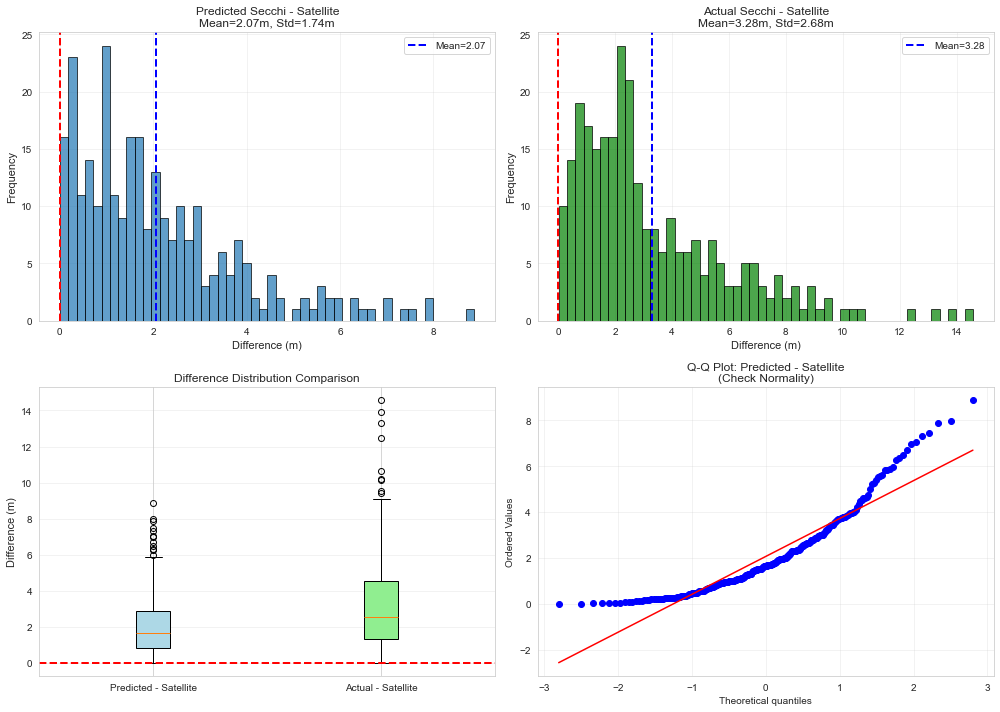

Saved: ../results/scatter_comparisons.png


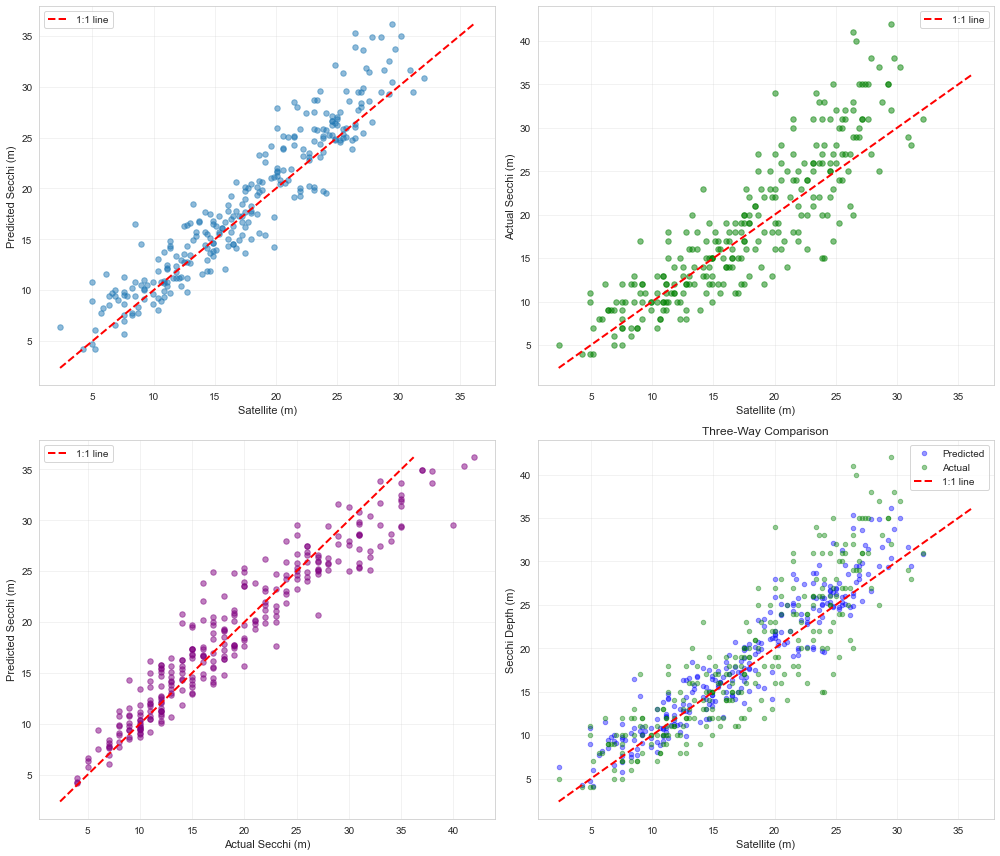

Saved: ../results/residual_plots.png


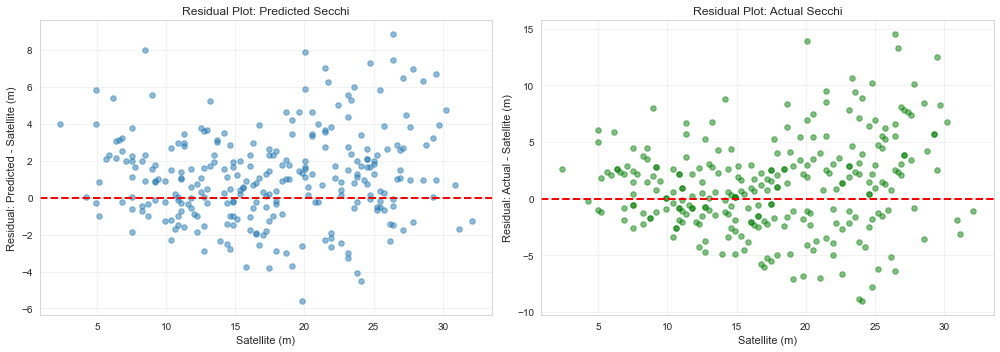

In [ ]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Set style
sns.set_style("whitegrid")

# ============================================================================
# Figure 1: Difference Distributions (Histograms)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted - Satellite
axes[0, 0].hist(df['Diff_Predicted_Satellite'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].axvline(df['Diff_Predicted_Satellite'].mean(), color='blue', 
                   linestyle='--', linewidth=2, label=f'Mean={df["Diff_Predicted_Satellite"].mean():.2f}')
axes[0, 0].set_xlabel('Difference (m)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title(f'Predicted Secchi - Satellite\nMean={df["Diff_Predicted_Satellite"].mean():.2f}m, Std={df["Diff_Predicted_Satellite"].std():.2f}m', 
                     fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual - Satellite
axes[0, 1].hist(df['Diff_Actual_Satellite'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(df['Diff_Actual_Satellite'].mean(), color='blue', 
                   linestyle='--', linewidth=2, label=f'Mean={df["Diff_Actual_Satellite"].mean():.2f}')
axes[0, 1].set_xlabel('Difference (m)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title(f'Actual Secchi - Satellite\nMean={df["Diff_Actual_Satellite"].mean():.2f}m, Std={df["Diff_Actual_Satellite"].std():.2f}m', 
                     fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Boxplot comparison
diff_data = [df['Diff_Predicted_Satellite'], df['Diff_Actual_Satellite']]
bp = axes[1, 0].boxplot(diff_data, labels=['Predicted - Satellite', 'Actual - Satellite'],
                        patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_ylabel('Difference (m)', fontsize=11)
axes[1, 0].set_title('Difference Distribution Comparison', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: QQ plot (check if differences are normally distributed)
stats.probplot(df['Diff_Predicted_Satellite'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Predicted - Satellite\n(Check Normality)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "difference_distributions.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'difference_distributions.png'}")
plt.show()

# ============================================================================
# Figure 2: Scatter Plots (Actual vs Predicted)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Predicted vs Satellite
axes[0, 0].scatter(df[satellite_col], df[predicted_col], alpha=0.5, s=30)
min_val = min(df[satellite_col].min(), df[predicted_col].min())
max_val = max(df[satellite_col].max(), df[predicted_col].max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')
axes[0, 0].set_xlabel('Satellite (m)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Secchi (m)', fontsize=11)
#axes[0, 0].set_title(f'Predicted vs Satellite\nR²={pred_sat_r2:.3f}, RMSE={pred_sat_rmse:.2f}m', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Satellite
axes[0, 1].scatter(df[satellite_col], df[actual_secchi_col], alpha=0.5, s=30, color='green')
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')
axes[0, 1].set_xlabel('Satellite (m)', fontsize=11)
axes[0, 1].set_ylabel('Actual Secchi (m)', fontsize=11)
#axes[0, 1].set_title(f'Actual vs Satellite\nR²={actual_sat_r2:.3f}, RMSE={actual_sat_rmse:.2f}m', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Predicted vs Actual
axes[1, 0].scatter(df[actual_secchi_col], df[predicted_col], alpha=0.5, s=30, color='purple')
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')
axes[1, 0].set_xlabel('Actual Secchi (m)', fontsize=11)
axes[1, 0].set_ylabel('Predicted Secchi (m)', fontsize=11)
#axes[1, 0].set_title(f'Predicted vs Actual\nR²={pred_actual_r2:.3f}, RMSE={pred_actual_rmse:.2f}m', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Three-way comparison
axes[1, 1].scatter(df[satellite_col], df[predicted_col], alpha=0.4, s=20, label='Predicted', color='blue')
axes[1, 1].scatter(df[satellite_col], df[actual_secchi_col], alpha=0.4, s=20, label='Actual', color='green')
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')
axes[1, 1].set_xlabel('Satellite (m)', fontsize=11)
axes[1, 1].set_ylabel('Secchi Depth (m)', fontsize=11)
axes[1, 1].set_title('Three-Way Comparison', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "scatter_comparisons.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'scatter_comparisons.png'}")
plt.show()

# ============================================================================
# Figure 3: Residual Plots (SIGNED residuals, not absolute)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Satellite (Predicted)
axes[0].scatter(
    df[satellite_col],
    df[predicted_col] - df[satellite_col],  # ← signed residuals
    alpha=0.5,
    s=30
)
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Satellite (m)', fontsize=11)
axes[0].set_ylabel('Residual: Predicted - Satellite (m)', fontsize=11)
axes[0].set_title('Residual Plot: Predicted Secchi', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals vs Satellite (Actual)
axes[1].scatter(
    df[satellite_col],
    df[actual_secchi_col] - df[satellite_col],  # ← signed residuals
    alpha=0.5,
    s=30,
    color='green'
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Satellite (m)', fontsize=11)
axes[1].set_ylabel('Residual: Actual - Satellite (m)', fontsize=11)
axes[1].set_title('Residual Plot: Actual Secchi', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "residual_plots.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'residual_plots.png'}")
plt.show()

## Checking with Pointvalue for polynomial regression

In [ ]:
df['Diff_Poly_Predicted_Satellite'] = df['Poly_Predicted_Secchi'] - df['Pointvalue']
df['Diff_Poly_Actual_Satellite'] = df['Secchi_x'] - df['Pointvalue']

print(f" \nPredicted - Satellite:")
print(f"  Mean: {df['Diff_Poly_Predicted_Satellite'].mean():.4f} m")
print(f"  Std:  {df['Diff_Poly_Predicted_Satellite'].std():.4f} m")

print(f"\nActual - Satellite:")
print(f"  Mean: {df['Diff_Poly_Actual_Satellite'].mean():.4f} m")
print(f"  Std:  {df['Diff_Poly_Actual_Satellite'].std():.4f} m")

# Scatterplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

min_val = min(df['Pointvalue'].min(), df['Poly_Predicted_Secchi'].min())
max_val = max(df['Pointvalue'].max(), df['Poly_Predicted_Secchi'].max())

axes[0].scatter(df['Pointvalue'], df['Poly_Predicted_Secchi'], alpha=0.5, s=30)
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')
axes[0].set_xlabel('Satellite (m)', fontsize=11)
axes[0].set_ylabel('Predicted Secchi (m)', fontsize=11)
axes[0].set_title('Poly Reg: Predicted vs Satellite', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['Pointvalue'], df['Secchi_x'], alpha=0.5, s=30, color='green')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')
axes[1].set_xlabel('Satellite (m)', fontsize=11)
axes[1].set_ylabel('Actual Secchi (m)', fontsize=11)
axes[1].set_title('Actual vs Satellite', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'Poly_Predicted_Secchi'